# Physics-Informed Neural Networks (PINNs) for Burgers' Equation

## 1. What are Physics-Informed Neural Networks (PINNs)?
Physics-Informed Neural Networks (PINNs) embed physical laws described by **Partial Differential Equations (PDEs)** directly into a neural network's loss function.

Unlike purely data-driven deep learning models, PINNs leverage automatic differentiation (via PyTorch `torch.autograd`) to compute exact derivatives of the neural network with respect to its spatio-temporal inputs $(t, x)$. This allows PINNs to:
- Learn physics-consistent solutions even with sparse, noisy, or no internal training data.
- Solve forward problems (finding $u(t, x)$ given initial/boundary conditions and known PDE coefficients).
- Solve inverse problems (discovering unknown parameters in physical equations from observations).

### Total Loss Function
The total objective function is a weighted combination of initial condition loss, boundary condition loss, and PDE residual loss:

$$\mathcal{L}_{total} = w_{IC} \mathcal{L}_{IC} + w_{BC} \mathcal{L}_{BC} + w_{PDE} \mathcal{L}_{PDE}$$

Where:
- **$\mathcal{L}_{IC}$**: Loss on Initial Condition at $t = 0$.
- **$\mathcal{L}_{BC}$**: Loss on Boundary Conditions ($x = -1, 1$).
- **$\mathcal{L}_{PDE}$**: Physics Residual Loss at domain collocation points $(t_i, x_i)$:
  $$\mathcal{L}_{PDE} = \frac{1}{N_{coll}} \sum_{i=1}^{N_{coll}} \left| f(t_i, x_i) \right|^2$$

---

## 2. The 1D Viscous Burgers' Equation
Burgers' equation is a fundamental non-linear PDE combining non-linear advection and diffusion, widely used in fluid dynamics and acoustics:

$$\frac{\partial u}{\partial t} + u \frac{\partial u}{\partial x} = \nu \frac{\partial^2 u}{\partial x^2}, \quad x \in [-1, 1], \quad t \in [0, 1]$$

Where:
- $u(t, x)$ is the velocity field.
- $\nu = \frac{0.01}{\pi} \approx 0.003183$ is the kinematic viscosity parameter.
- **Initial Condition (IC)**: $u(0, x) = -\sin(\pi x), \quad x \in [-1, 1]$
- **Boundary Conditions (BC)**: $u(t, -1) = 0$ and $u(t, 1) = 0, \quad t \in [0, 1]$

### PDE Residual Definition:
$$f(t, x) \equiv \frac{\partial u}{\partial t} + u \frac{\partial u}{\partial x} - \nu \frac{\partial^2 u}{\partial x^2} = 0$$


In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import time

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cpu


In [2]:
class PINN(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=30, num_layers=4, output_dim=1):
        super(PINN, self).__init__()
        layers = []
        layers.append(nn.Linear(input_dim, hidden_dim))
        layers.append(nn.Tanh())
        
        for _ in range(num_layers - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.Tanh())
            
        layers.append(nn.Linear(hidden_dim, output_dim))
        self.network = nn.Sequential(*layers)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, t, x):
        inputs = torch.cat([t, x], dim=1)
        return self.network(inputs)

    def pde_residual(self, t, x, nu=0.01 / np.pi):
        t.requires_grad_(True)
        x.requires_grad_(True)
        
        u = self.forward(t, x)
        
        u_t = torch.autograd.grad(
            u, t, grad_outputs=torch.ones_like(u),
            create_graph=True, retain_graph=True
        )[0]
        
        u_x = torch.autograd.grad(
            u, x, grad_outputs=torch.ones_like(u),
            create_graph=True, retain_graph=True
        )[0]
        
        u_xx = torch.autograd.grad(
            u_x, x, grad_outputs=torch.ones_like(u_x),
            create_graph=True, retain_graph=True
        )[0]
        
        residual = u_t + u * u_x - nu * u_xx
        return residual


In [3]:
def generate_training_data(N_ic=100, N_bc=100, N_f=2000):
    # Initial Condition: t = 0, x in [-1, 1], u(0, x) = -sin(pi * x)
    x_ic = np.random.uniform(-1.0, 1.0, (N_ic, 1))
    t_ic = np.zeros((N_ic, 1))
    u_ic = -np.sin(np.pi * x_ic)
    
    # Boundary Conditions: x = -1 and x = 1, t in [0, 1], u(t, -1) = u(t, 1) = 0
    t_bc = np.random.uniform(0.0, 1.0, (N_bc, 1))
    x_bc_left = -np.ones((N_bc // 2, 1))
    x_bc_right = np.ones((N_bc // 2, 1))
    
    t_bc_combined = np.vstack([t_bc[:N_bc // 2], t_bc[N_bc // 2:]])
    x_bc_combined = np.vstack([x_bc_left, x_bc_right])
    u_bc_combined = np.zeros((N_bc, 1))
    
    # Collocation Points inside domain: t in [0, 1], x in [-1, 1]
    t_f = np.random.uniform(0.0, 1.0, (N_f, 1))
    x_f = np.random.uniform(-1.0, 1.0, (N_f, 1))
    
    # Convert to PyTorch Tensors
    t_ic_tensor = torch.tensor(t_ic, dtype=torch.float32).to(device)
    x_ic_tensor = torch.tensor(x_ic, dtype=torch.float32).to(device)
    u_ic_tensor = torch.tensor(u_ic, dtype=torch.float32).to(device)
    
    t_bc_tensor = torch.tensor(t_bc_combined, dtype=torch.float32).to(device)
    x_bc_tensor = torch.tensor(x_bc_combined, dtype=torch.float32).to(device)
    u_bc_tensor = torch.tensor(u_bc_combined, dtype=torch.float32).to(device)
    
    t_f_tensor = torch.tensor(t_f, dtype=torch.float32).to(device)
    x_f_tensor = torch.tensor(x_f, dtype=torch.float32).to(device)
    
    return (t_ic_tensor, x_ic_tensor, u_ic_tensor), \
           (t_bc_tensor, x_bc_tensor, u_bc_tensor), \
           (t_f_tensor, x_f_tensor)

(t_ic, x_ic, u_ic), (t_bc, x_bc, u_bc), (t_f, x_f) = generate_training_data()
print(f"Sampled {t_ic.shape[0]} IC points, {t_bc.shape[0]} BC points, and {t_f.shape[0]} PDE collocation points.")


Sampled 100 IC points, 100 BC points, and 2000 PDE collocation points.


In [4]:
model = PINN(input_dim=2, hidden_dim=30, num_layers=4, output_dim=1).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=3e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=150)

nu = 0.01 / np.pi
epochs = 800
loss_history = []

start_time = time.time()

for epoch in range(1, epochs + 1):
    optimizer.zero_grad()
    
    # Initial condition loss
    u_ic_pred = model(t_ic, x_ic)
    loss_ic = torch.mean((u_ic_pred - u_ic) ** 2)
    
    # Boundary condition loss
    u_bc_pred = model(t_bc, x_bc)
    loss_bc = torch.mean((u_bc_pred - u_bc) ** 2)
    
    # PDE residual loss
    f_pde_pred = model.pde_residual(t_f, x_f, nu=nu)
    loss_pde = torch.mean(f_pde_pred ** 2)
    
    # Total loss
    loss = 2.0 * loss_ic + 2.0 * loss_bc + loss_pde
    
    loss.backward()
    optimizer.step()
    scheduler.step(loss)
    
    loss_history.append(loss.item())
    
    if epoch % 200 == 0 or epoch == 1:
        print(f"Epoch {epoch:4d}/{epochs} | Total Loss: {loss.item():.6e} | IC Loss: {loss_ic.item():.6e} | BC Loss: {loss_bc.item():.6e} | PDE Loss: {loss_pde.item():.6e}")

elapsed = time.time() - start_time
print(f"Training completed in {elapsed:.2f} seconds.")


c:\Users\HP\Desktop\sentientAI\.venv\Lib\site-packages\torch\optim\lr_scheduler.py:1699: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:823.)
  current = float(metrics)


Epoch    1/800 | Total Loss: 1.222632e+00 | IC Loss: 5.973768e-01 | BC Loss: 1.340217e-02 | PDE Loss: 1.074277e-03
Epoch  200/800 | Total Loss: 2.068978e-01 | IC Loss: 4.830186e-02 | BC Loss: 4.261658e-03 | PDE Loss: 1.017708e-01
Epoch  400/800 | Total Loss: 1.406435e-01 | IC Loss: 3.046511e-02 | BC Loss: 4.939281e-04 | PDE Loss: 7.872540e-02
Epoch  600/800 | Total Loss: 1.197247e-01 | IC Loss: 2.465368e-02 | BC Loss: 3.173876e-04 | PDE Loss: 6.978256e-02
Epoch  800/800 | Total Loss: 1.039714e-01 | IC Loss: 2.177291e-02 | BC Loss: 2.179351e-04 | PDE Loss: 5.998974e-02
Training completed in 11.54 seconds.


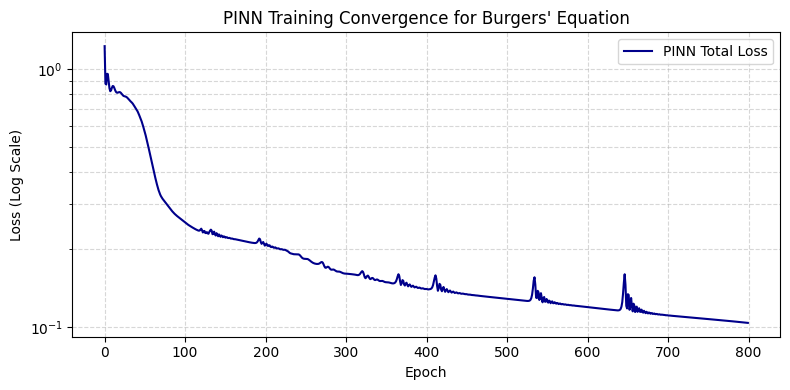

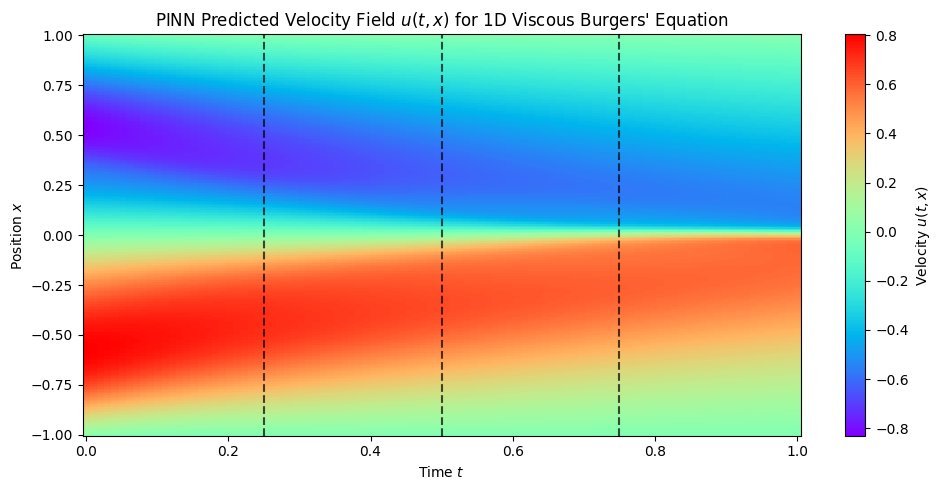

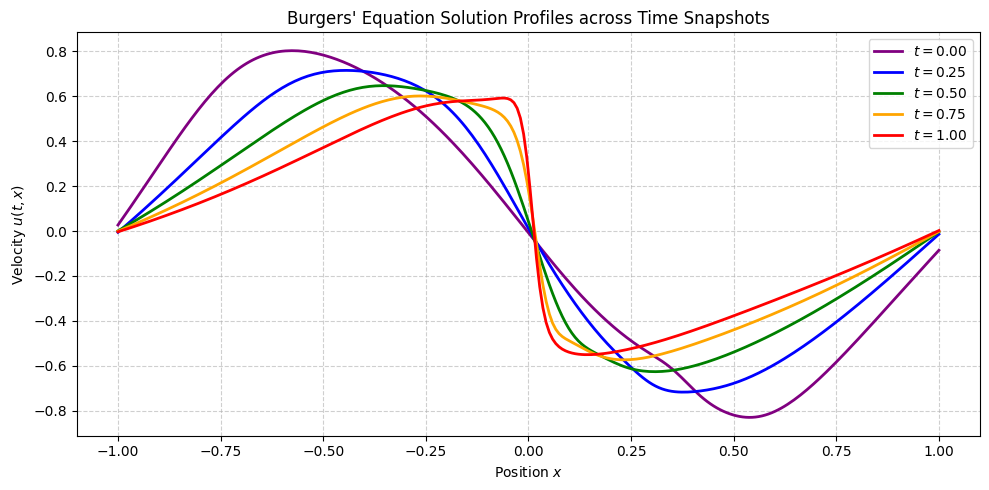

In [5]:
# Create grid for evaluating the solution u(t, x)
t_grid = np.linspace(0.0, 1.0, 100)
x_grid = np.linspace(-1.0, 1.0, 256)
T, X = np.meshgrid(t_grid, x_grid)

t_flat = torch.tensor(T.flatten()[:, None], dtype=torch.float32).to(device)
x_flat = torch.tensor(X.flatten()[:, None], dtype=torch.float32).to(device)

model.eval()
with torch.no_grad():
    u_pred_flat = model(t_flat, x_flat)
    
U_pred = u_pred_flat.cpu().numpy().reshape(X.shape)

# Figure 1: Training Loss Convergence
plt.figure(figsize=(8, 4))
plt.plot(loss_history, label='PINN Total Loss', color='darkblue', lw=1.5)
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss (Log Scale)')
plt.title("PINN Training Convergence for Burgers' Equation")
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# Figure 2: Spatiotemporal Velocity Field u(t, x) Heatmap
plt.figure(figsize=(10, 5))
cp = plt.pcolormesh(T, X, U_pred, cmap='rainbow', shading='auto')
plt.colorbar(cp, label='Velocity $u(t, x)$')
plt.xlabel('Time $t$')
plt.ylabel('Position $x$')
plt.title("PINN Predicted Velocity Field $u(t, x)$ for 1D Viscous Burgers' Equation")
plt.axvline(x=0.25, color='black', linestyle='--', alpha=0.7)
plt.axvline(x=0.50, color='black', linestyle='--', alpha=0.7)
plt.axvline(x=0.75, color='black', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Figure 3: Time-slice profiles demonstrating shock wave formation
plt.figure(figsize=(10, 5))
time_snapshots = [0.0, 0.25, 0.50, 0.75, 1.0]
colors = ['purple', 'blue', 'green', 'orange', 'red']

for t_val, col in zip(time_snapshots, colors):
    t_idx = int(t_val * (len(t_grid) - 1))
    plt.plot(x_grid, U_pred[:, t_idx], label=f'$t = {t_val:.2f}$', color=col, lw=2)

plt.xlabel('Position $x$')
plt.ylabel('Velocity $u(t, x)$')
plt.title("Burgers' Equation Solution Profiles across Time Snapshots")
plt.grid(True, ls='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


---

# Physics-Informed Neural Networks (PINNs) for 1D Non-Linear Schrödinger (NLS) Equation

## 1. Mathematical Formulation
The 1D Non-Linear Schrödinger equation is a canonical integrable PDE governing the evolution of quantum wave packets, optical soliton propagation in non-linear media, and deep water waves:

$$i \frac{\partial \psi}{\partial t} + 0.5 \frac{\partial^2 \psi}{\partial x^2} + |\psi|^2 \psi = 0, \quad x \in [-5, 5], \quad t \in [0, \pi/2]$$

Where:
- $\psi(t, x) = u(t, x) + i v(t, x)$ is the complex-valued wave function with real part $u(t, x)$ and imaginary part $v(t, x)$.
- $|\psi(t, x)|^2 = u(t, x)^2 + v(t, x)^2$ is the probability density / wave intensity.

### Coupled Real PDEs
Substituting $\psi = u + iv$ into the Schrödinger equation yields a system of two coupled real-valued PDEs:
$$\begin{cases}
f_u \equiv \frac{\partial u}{\partial t} + 0.5 \frac{\partial^2 v}{\partial x^2} + (u^2 + v^2) v = 0 \\[6pt]
f_v \equiv \frac{\partial v}{\partial t} - 0.5 \frac{\partial^2 u}{\partial x^2} - (u^2 + v^2) u = 0
\end{cases}$$

### Initial and Boundary Conditions
- **Initial Condition (IC)** ($t = 0$):
  $$\psi(0, x) = 2 \operatorname{sech}(x) \implies u(0, x) = \frac{2}{\cosh(x)}, \quad v(0, x) = 0$$
- **Periodic Boundary Conditions (BC)** ($x = -5, 5$):
  $$\begin{cases}
  u(t, -5) = u(t, 5), & \frac{\partial u}{\partial x}(t, -5) = \frac{\partial u}{\partial x}(t, 5) \\[4pt]
  v(t, -5) = v(t, 5), & \frac{\partial v}{\partial x}(t, -5) = \frac{\partial v}{\partial x}(t, 5)
  \end{cases}$$


In [6]:
# Define Multi-Output PINN Architecture for Schrödinger Equation (Predicting [u, v])
class SchrodingerPINN(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=40, num_layers=4, output_dim=2):
        super(SchrodingerPINN, self).__init__()
        layers = []
        layers.append(nn.Linear(input_dim, hidden_dim))
        layers.append(nn.Tanh())
        
        for _ in range(num_layers - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.Tanh())
            
        layers.append(nn.Linear(hidden_dim, output_dim))
        self.network = nn.Sequential(*layers)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, t, x):
        inputs = torch.cat([t, x], dim=1)
        return self.network(inputs)

    def pde_residual(self, t, x):
        t.requires_grad_(True)
        x.requires_grad_(True)
        
        uv = self.forward(t, x)
        u = uv[:, 0:1]
        v = uv[:, 1:2]
        
        # Derivatives for u (real component)
        u_t = torch.autograd.grad(
            u, t, grad_outputs=torch.ones_like(u),
            create_graph=True, retain_graph=True
        )[0]
        u_x = torch.autograd.grad(
            u, x, grad_outputs=torch.ones_like(u),
            create_graph=True, retain_graph=True
        )[0]
        u_xx = torch.autograd.grad(
            u_x, x, grad_outputs=torch.ones_like(u_x),
            create_graph=True, retain_graph=True
        )[0]
        
        # Derivatives for v (imaginary component)
        v_t = torch.autograd.grad(
            v, t, grad_outputs=torch.ones_like(v),
            create_graph=True, retain_graph=True
        )[0]
        v_x = torch.autograd.grad(
            v, x, grad_outputs=torch.ones_like(v),
            create_graph=True, retain_graph=True
        )[0]
        v_xx = torch.autograd.grad(
            v_x, x, grad_outputs=torch.ones_like(v_x),
            create_graph=True, retain_graph=True
        )[0]
        
        # Coupled Schrödinger Residuals
        f_u = u_t + 0.5 * v_xx + (u**2 + v**2) * v
        f_v = v_t - 0.5 * u_xx - (u**2 + v**2) * u
        
        return f_u, f_v


def generate_schrodinger_data(N_ic=200, N_bc=100, N_f=2000):
    # Initial Condition: t = 0, x in [-5, 5], psi(0, x) = 2 / cosh(x)
    x_ic = np.random.uniform(-5.0, 5.0, (N_ic, 1))
    t_ic = np.zeros((N_ic, 1))
    u_ic = 2.0 / np.cosh(x_ic)
    v_ic = np.zeros((N_ic, 1))
    
    # Periodic Boundary Condition Points: x = -5 and x = +5, t in [0, pi/2]
    t_bc = np.random.uniform(0.0, np.pi / 2.0, (N_bc, 1))
    x_bc_lb = -5.0 * np.ones((N_bc, 1))
    x_bc_ub = 5.0 * np.ones((N_bc, 1))
    
    # Collocation Points inside domain: t in [0, pi/2], x in [-5, 5]
    t_f = np.random.uniform(0.0, np.pi / 2.0, (N_f, 1))
    x_f = np.random.uniform(-5.0, 5.0, (N_f, 1))
    
    # Convert to PyTorch Tensors
    return (
        (torch.tensor(t_ic, dtype=torch.float32).to(device),
         torch.tensor(x_ic, dtype=torch.float32).to(device),
         torch.tensor(u_ic, dtype=torch.float32).to(device),
         torch.tensor(v_ic, dtype=torch.float32).to(device)),
        (torch.tensor(t_bc, dtype=torch.float32).to(device),
         torch.tensor(x_bc_lb, dtype=torch.float32).to(device),
         torch.tensor(x_bc_ub, dtype=torch.float32).to(device)),
        (torch.tensor(t_f, dtype=torch.float32).to(device),
         torch.tensor(x_f, dtype=torch.float32).to(device))
    )

(t_ic_nls, x_ic_nls, u_ic_nls, v_ic_nls), (t_bc_nls, x_bc_lb_nls, x_bc_ub_nls), (t_f_nls, x_f_nls) = generate_schrodinger_data()
print(f"Sampled {t_ic_nls.shape[0]} IC points, {t_bc_nls.shape[0]} BC points, and {t_f_nls.shape[0]} NLS Collocation points.")


Sampled 200 IC points, 100 BC points, and 2000 NLS Collocation points.


In [7]:
# Initialize Schrödinger PINN and Optimizer
model_nls = SchrodingerPINN(input_dim=2, hidden_dim=40, num_layers=4, output_dim=2).to(device)
optimizer_nls = torch.optim.Adam(model_nls.parameters(), lr=2e-3)
scheduler_nls = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_nls, mode='min', factor=0.5, patience=150)

epochs_nls = 800
loss_history_nls = []

start_time = time.time()

for epoch in range(1, epochs_nls + 1):
    optimizer_nls.zero_grad()
    
    # 1. Initial Condition Loss: u(0, x) = 2*sech(x), v(0, x) = 0
    uv_ic_pred = model_nls(t_ic_nls, x_ic_nls)
    loss_ic = torch.mean((uv_ic_pred[:, 0:1] - u_ic_nls)**2) + torch.mean((uv_ic_pred[:, 1:2] - v_ic_nls)**2)
    
    # 2. Periodic Boundary Condition Loss: u, v, u_x, v_x at lower and upper boundaries
    x_bc_lb_nls.requires_grad_(True)
    x_bc_ub_nls.requires_grad_(True)
    uv_lb = model_nls(t_bc_nls, x_bc_lb_nls)
    uv_ub = model_nls(t_bc_nls, x_bc_ub_nls)
    u_lb, v_lb = uv_lb[:, 0:1], uv_lb[:, 1:2]
    u_ub, v_ub = uv_ub[:, 0:1], uv_ub[:, 1:2]
    
    u_x_lb = torch.autograd.grad(u_lb, x_bc_lb_nls, grad_outputs=torch.ones_like(u_lb), create_graph=True)[0]
    u_x_ub = torch.autograd.grad(u_ub, x_bc_ub_nls, grad_outputs=torch.ones_like(u_ub), create_graph=True)[0]
    v_x_lb = torch.autograd.grad(v_lb, x_bc_lb_nls, grad_outputs=torch.ones_like(v_lb), create_graph=True)[0]
    v_x_ub = torch.autograd.grad(v_ub, x_bc_ub_nls, grad_outputs=torch.ones_like(v_ub), create_graph=True)[0]
    
    loss_bc = torch.mean((u_lb - u_ub)**2) + torch.mean((v_lb - v_ub)**2) + \
              torch.mean((u_x_lb - u_x_ub)**2) + torch.mean((v_x_lb - v_x_ub)**2)
    
    # 3. Physics Residual Loss: f_u^2 + f_v^2
    f_u_pred, f_v_pred = model_nls.pde_residual(t_f_nls, x_f_nls)
    loss_pde = torch.mean(f_u_pred**2) + torch.mean(f_v_pred**2)
    
    # Total Loss
    loss = 2.0 * loss_ic + 1.5 * loss_bc + loss_pde
    
    loss.backward()
    optimizer_nls.step()
    scheduler_nls.step(loss)
    
    loss_history_nls.append(loss.item())
    
    if epoch % 200 == 0 or epoch == 1:
        print(f"Epoch {epoch:4d}/{epochs_nls} | Total Loss: {loss.item():.6e} | IC Loss: {loss_ic.item():.6e} | BC Loss: {loss_bc.item():.6e} | PDE Loss: {loss_pde.item():.6e}")

elapsed_nls = time.time() - start_time
print(f"Schrödinger PINN training completed in {elapsed_nls:.2f} seconds.")


Epoch    1/800 | Total Loss: 2.475777e+00 | IC Loss: 9.733625e-01 | BC Loss: 2.913401e-01 | PDE Loss: 9.204164e-02
Epoch  200/800 | Total Loss: 9.470002e-02 | IC Loss: 1.819590e-02 | BC Loss: 1.381207e-03 | PDE Loss: 5.623641e-02
Epoch  400/800 | Total Loss: 7.489632e-02 | IC Loss: 1.264796e-02 | BC Loss: 3.368736e-04 | PDE Loss: 4.909509e-02
Epoch  600/800 | Total Loss: 6.550296e-02 | IC Loss: 1.103592e-02 | BC Loss: 1.626215e-04 | PDE Loss: 4.318719e-02
Epoch  800/800 | Total Loss: 5.712672e-02 | IC Loss: 9.420153e-03 | BC Loss: 1.528160e-04 | PDE Loss: 3.805719e-02
Schrödinger PINN training completed in 29.88 seconds.


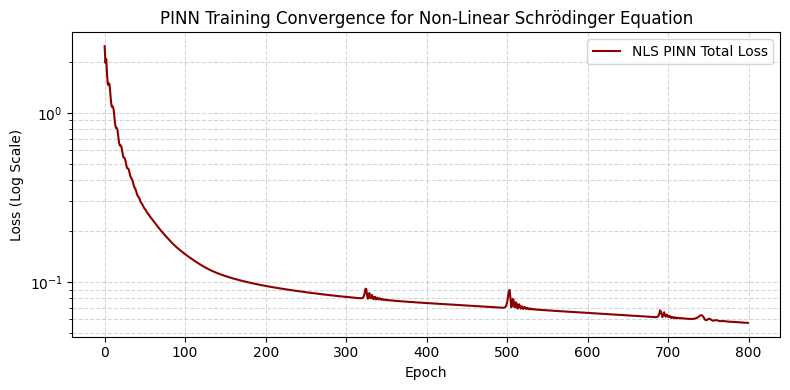

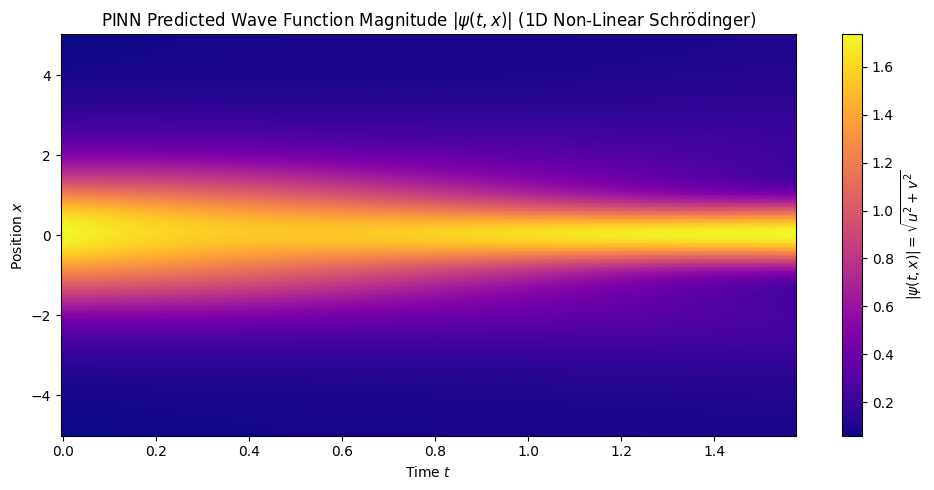

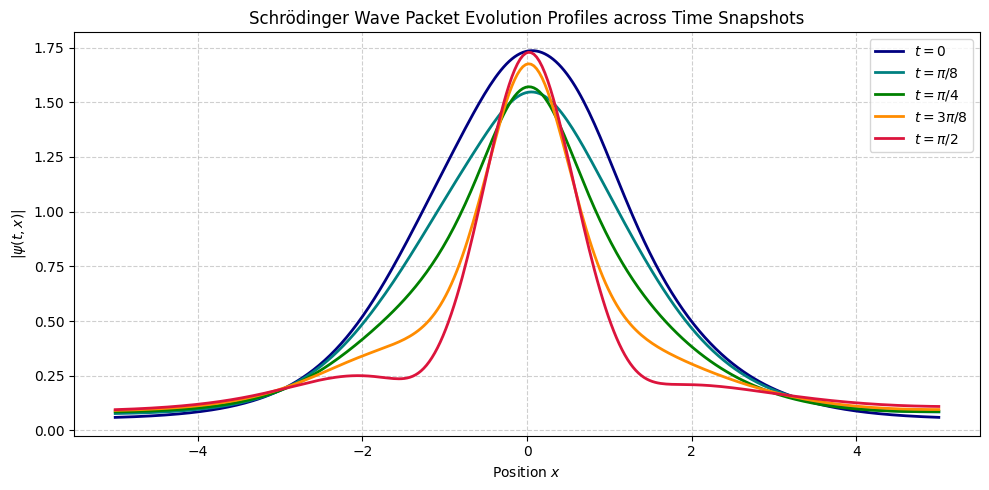

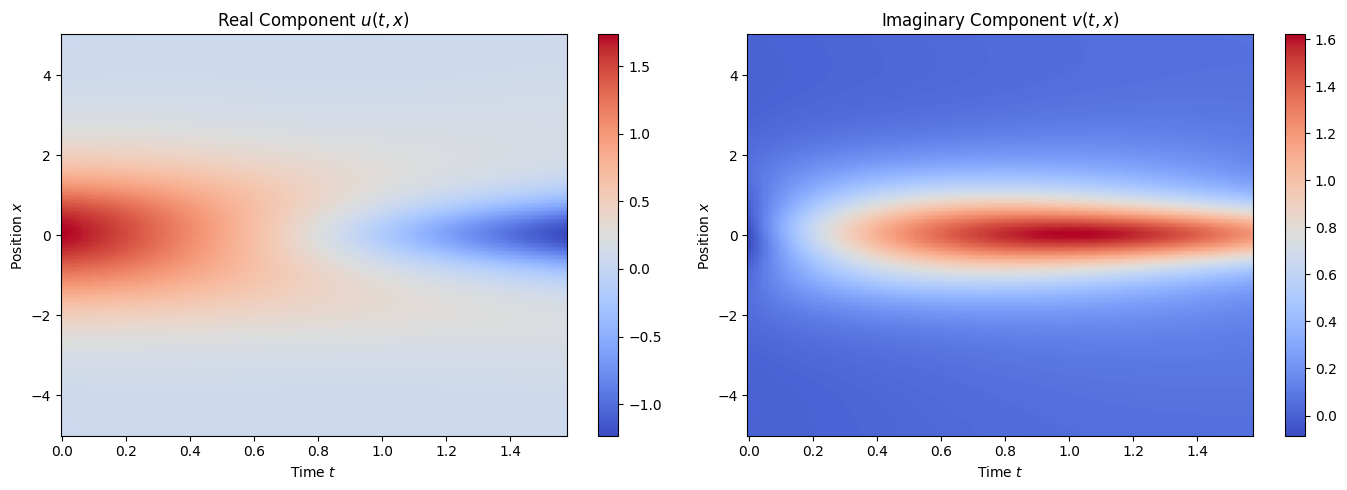

In [8]:
# Create Spatiotemporal Grid for Schrödinger Equation Evaluation: t in [0, pi/2], x in [-5, 5]
t_grid_nls = np.linspace(0.0, np.pi / 2.0, 150)
x_grid_nls = np.linspace(-5.0, 5.0, 300)
T_nls, X_nls = np.meshgrid(t_grid_nls, x_grid_nls)

t_flat_nls = torch.tensor(T_nls.flatten()[:, None], dtype=torch.float32).to(device)
x_flat_nls = torch.tensor(X_nls.flatten()[:, None], dtype=torch.float32).to(device)

model_nls.eval()
with torch.no_grad():
    uv_pred_flat = model_nls(t_flat_nls, x_flat_nls)
    u_pred_nls = uv_pred_flat[:, 0:1].cpu().numpy().reshape(X_nls.shape)
    v_pred_nls = uv_pred_flat[:, 1:2].cpu().numpy().reshape(X_nls.shape)
    psi_mag_pred = np.sqrt(u_pred_nls**2 + v_pred_nls**2)

# Figure 1: Training Loss Convergence for Schrödinger PINN
plt.figure(figsize=(8, 4))
plt.plot(loss_history_nls, label='NLS PINN Total Loss', color='darkred', lw=1.5)
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss (Log Scale)')
plt.title('PINN Training Convergence for Non-Linear Schrödinger Equation')
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# Figure 2: Spatiotemporal Wave Function Magnitude |psi(t, x)| Heatmap
plt.figure(figsize=(10, 5))
cp = plt.pcolormesh(T_nls, X_nls, psi_mag_pred, cmap='plasma', shading='auto')
plt.colorbar(cp, label=r'$|\psi(t, x)| = \sqrt{u^2 + v^2}$')
plt.xlabel(r'Time $t$')
plt.ylabel(r'Position $x$')
plt.title(r'PINN Predicted Wave Function Magnitude $|\psi(t, x)|$ (1D Non-Linear Schrödinger)')
plt.tight_layout()
plt.show()

# Figure 3: Time-slice profiles of |psi(t, x)| across evolution
plt.figure(figsize=(10, 5))
time_snapshots_nls = [0.0, np.pi/8, np.pi/4, 3*np.pi/8, np.pi/2]
labels = [r'$t = 0$', r'$t = \pi/8$', r'$t = \pi/4$', r'$t = 3\pi/8$', r'$t = \pi/2$']
colors_nls = ['navy', 'teal', 'green', 'darkorange', 'crimson']

for t_val, lbl, col in zip(time_snapshots_nls, labels, colors_nls):
    t_idx = np.argmin(np.abs(t_grid_nls - t_val))
    plt.plot(x_grid_nls, psi_mag_pred[:, t_idx], label=lbl, color=col, lw=2)

plt.xlabel(r'Position $x$')
plt.ylabel(r'$|\psi(t, x)|$')
plt.title('Schrödinger Wave Packet Evolution Profiles across Time Snapshots')
plt.grid(True, ls='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# Figure 4: Real (u) and Imaginary (v) Components Heatmaps
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
im1 = axes[0].pcolormesh(T_nls, X_nls, u_pred_nls, cmap='coolwarm', shading='auto')
axes[0].set_title(r'Real Component $u(t, x)$')
axes[0].set_xlabel(r'Time $t$')
axes[0].set_ylabel(r'Position $x$')
fig.colorbar(im1, ax=axes[0])

im2 = axes[1].pcolormesh(T_nls, X_nls, v_pred_nls, cmap='coolwarm', shading='auto')
axes[1].set_title(r'Imaginary Component $v(t, x)$')
axes[1].set_xlabel(r'Time $t$')
axes[1].set_ylabel(r'Position $x$')
fig.colorbar(im2, ax=axes[1])
plt.tight_layout()
plt.show()
